# ISMN Soil Moisture — Station Presence by EPA Ecoregion Level

Mirrors `visualize_ISMN.py` but replaces U.S. state borders with EPA ecoregion boundaries at every level (I → IV). Ecoregions that contain at least one ISMN station are coloured by station count; grey regions have no stations.

In [1]:
from __future__ import annotations

import io
import math
import zipfile
from pathlib import Path

import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

# ── paths ──────────────────────────────────────────────────────────────────
ROOT = Path(".")
CSV_PATH = ROOT / "ISMN_dataset" / "sm_station_month_means.csv"
ECO_DIR  = ROOT / "ISMN_dataset" / "ecoregions"
ECO_DIR.mkdir(parents=True, exist_ok=True)

# ── user-facing knobs ──────────────────────────────────────────────────────
MONTH    = None
EXTENT   = (-125.0, -66.5, 24.0, 50.0)   # lon_min, lon_max, lat_min, lat_max
DOT_SIZE = 9
OUTPUT   = ROOT / "visualize_ismn_ecoregions.png"

# ── ecoregion level metadata (Levels I–III only) ───────────────────────────
# NA_L*CODE columns carry the hierarchical dotted codes (e.g. "8.1", "8.1.3").
# US_L3CODE is just a sequential integer (1–104) — not used here.
LEVELS = [
    {"key": "I",   "code": "NA_L1CODE", "name": "NA_L1NAME", "label": "Level I",   "src": "l3"},
    {"key": "II",  "code": "NA_L2CODE", "name": "NA_L2NAME", "label": "Level II",  "src": "l3"},
    {"key": "III", "code": "NA_L3CODE", "name": "NA_L3NAME", "label": "Level III", "src": "l3"},
]

## 1 · Load ISMN station data

In [2]:
def load_ismn_points(csv_path: Path, month: str | None = None) -> pd.DataFrame:
    required = ["station_month_mean", "lat", "lon"]
    if month:
        required.append("month")
    df = pd.read_csv(csv_path, usecols=lambda c: c in set(required))
    missing = sorted(set(required) - set(df.columns))
    if missing:
        raise ValueError(f"{csv_path} is missing required columns: {', '.join(missing)}")
    if month:
        df = df[df["month"] == month]
    df = df.dropna(subset=["station_month_mean", "lat", "lon"])
    df = df[(df["lat"].between(-90, 90)) & (df["lon"].between(-180, 180))]
    return df[["lat", "lon"]].drop_duplicates().reset_index(drop=True)


points = load_ismn_points(CSV_PATH, month=MONTH)
print(f"Loaded {len(points):,} unique ISMN station locations")

points_gdf = gpd.GeoDataFrame(
    points,
    geometry=gpd.points_from_xy(points["lon"], points["lat"]),
    crs="EPSG:4326",
)
points_gdf.head()

Loaded 965 unique ISMN station locations


,lat,lon,geometry
0,44.91670,-68.73590,POINT (-68.7359 44.9167)
1,35.67920,-105.82690,POINT (-105.8269 35.6792)
2,40.17179,-103.22248,POINT (-103.22248 40.17179)
3,43.00177,-119.95179,POINT (-119.95179 43.00177)
4,36.42028,-105.29365,POINT (-105.29365 36.42028)


## 2 · Download EPA ecoregion shapefiles (cached)

Files are fetched once from the EPA FTP and cached under `ISMN_dataset/ecoregions/`.

| File | Levels covered | Approx. size |
|---|---|---|
| `us_eco_l3.zip` | I, II, III | ~10 MB |
| `us_eco_l4_no_st.zip` | IV | ~25 MB |

In [3]:
# EPA ecoregion shapefiles moved to S3 (old gaftp.epa.gov/EPADataCommons path returns 404)
EPA_S3 = "https://dmap-prod-oms-edc.s3.us-east-1.amazonaws.com/ORD/Ecoregions/us"

SOURCES = {
    "l3": {
        "url": f"{EPA_S3}/us_eco_l3.zip",
        "dir": ECO_DIR / "us_eco_l3",
        "shp": ECO_DIR / "us_eco_l3" / "us_eco_l3.shp",
    },
    "l4": {
        "url": f"{EPA_S3}/us_eco_l4.zip",
        "dir": ECO_DIR / "us_eco_l4",
        # zip extracts as us_eco_l4_no_st.shp (state boundaries stripped inside)
        "shp": ECO_DIR / "us_eco_l4" / "us_eco_l4_no_st.shp",
    },
}


def fetch_ecoregion_zip(src_key: str) -> None:
    src = SOURCES[src_key]
    if src["shp"].exists():
        print(f"[{src_key}] already cached at {src['shp']}")
        return
    print(f"[{src_key}] downloading {src['url']} …", end=" ", flush=True)
    r = requests.get(src["url"], timeout=180)
    r.raise_for_status()
    src["dir"].mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall(src["dir"])
    print("done")


fetch_ecoregion_zip("l3")
fetch_ecoregion_zip("l4")

[l3] already cached at ISMN_dataset/ecoregions/us_eco_l3/us_eco_l3.shp
[l4] already cached at ISMN_dataset/ecoregions/us_eco_l4/us_eco_l4_no_st.shp


## 3 · Load ecoregion GeoDataFrames

In [4]:
eco_raw = {
    key: gpd.read_file(SOURCES[key]["shp"]).to_crs("EPSG:4326")
    for key in ("l3", "l4")
}

for key, gdf in eco_raw.items():
    print(f"[{key}] {len(gdf):,} polygons | columns: {gdf.columns.tolist()}")

[l3] 1,250 polygons | columns: ['US_L3CODE', 'US_L3NAME', 'NA_L3CODE', 'NA_L3NAME', 'NA_L2CODE', 'NA_L2NAME', 'NA_L1CODE', 'NA_L1NAME', 'L3_KEY', 'L2_KEY', 'L1_KEY', 'Shape_Leng', 'Shape_Area', 'geometry']
[l4] 5,896 polygons | columns: ['US_L4CODE', 'US_L4NAME', 'US_L3CODE', 'US_L3NAME', 'NA_L3CODE', 'NA_L3NAME', 'NA_L2CODE', 'NA_L2NAME', 'NA_L1CODE', 'NA_L1NAME', 'L4_KEY', 'L3_KEY', 'L2_KEY', 'L1_KEY', 'Shape_Leng', 'Shape_Area', 'geometry']


## 4 · Spatial join — assign each ISMN station to its ecoregion

In [5]:
# Join each station to the L4 GDF (which carries NA_L1CODE, NA_L2CODE, NA_L3CODE).
# Stations outside CONUS will have NaN for all level codes.

level_cols = ["NA_L1CODE", "NA_L2CODE", "NA_L3CODE"]
available_cols = [c for c in level_cols if c in eco_raw["l4"].columns]

joined = gpd.sjoin(
    points_gdf,
    eco_raw["l4"][[*available_cols, "geometry"]],
    how="left",
    predicate="within",
)
matched = joined["NA_L3CODE"].notna().sum() if "NA_L3CODE" in joined.columns else 0
print(f"Stations matched to an ecoregion: {matched:,} / {len(joined):,}")

# Fall back: for stations not matched by 'within', try 'nearest'
unmatched_mask = joined["NA_L3CODE"].isna() if "NA_L3CODE" in joined.columns else pd.Series([True]*len(joined))
if unmatched_mask.any():
    fallback = gpd.sjoin_nearest(
        points_gdf[unmatched_mask],
        eco_raw["l4"][[*available_cols, "geometry"]],
        how="left",
        max_distance=0.5,
    )
    for col in available_cols:
        joined.loc[unmatched_mask, col] = fallback[col].values
    print(f"Recovered {unmatched_mask.sum()} unmatched stations via nearest-join")
    print(f"Final matched: {joined['NA_L3CODE'].notna().sum():,} / {len(joined):,}")

Stations matched to an ecoregion: 885 / 965
Recovered 80 unmatched stations via nearest-join
Final matched: 885 / 965


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/geopandas/array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


## 5 · Build per-level dissolved GeoDataFrames with station counts

In [6]:
def build_level_gdf(level_cfg: dict) -> gpd.GeoDataFrame:
    code_col = level_cfg["code"]
    name_col = level_cfg["name"]
    src_key  = level_cfg["src"]
    raw      = eco_raw[src_key]

    keep_cols = [c for c in [code_col, name_col, "geometry"] if c in raw.columns]
    dissolved = raw.dissolve(by=code_col, as_index=False)[keep_cols]

    if code_col in joined.columns:
        counts = (
            joined[joined[code_col].notna()]
            .groupby(code_col)
            .size()
            .reset_index(name="station_count")
        )
        dissolved = dissolved.merge(counts, on=code_col, how="left")
    else:
        dissolved["station_count"] = 0

    dissolved["station_count"] = dissolved["station_count"].fillna(0).astype(int)
    dissolved["has_stations"]  = dissolved["station_count"] > 0
    return dissolved


level_gdfs = {cfg["key"]: build_level_gdf(cfg) for cfg in LEVELS}

print(f"{'Level':<8} {'Regions':>8} {'With stations':>15} {'Coverage':>10}")
print("-" * 45)
for lvl, gdf in level_gdfs.items():
    total   = len(gdf)
    covered = int(gdf["has_stations"].sum())
    print(f"{lvl:<8} {total:>8,} {covered:>15,} {100*covered/total:>9.1f}%")

Level     Regions   With stations   Coverage
---------------------------------------------
I              10              10     100.0%
II             20              20     100.0%
III            84              73      86.9%


## 6 · Visualise all four ecoregion levels

Saved visualize_ismn_ecoregions.png


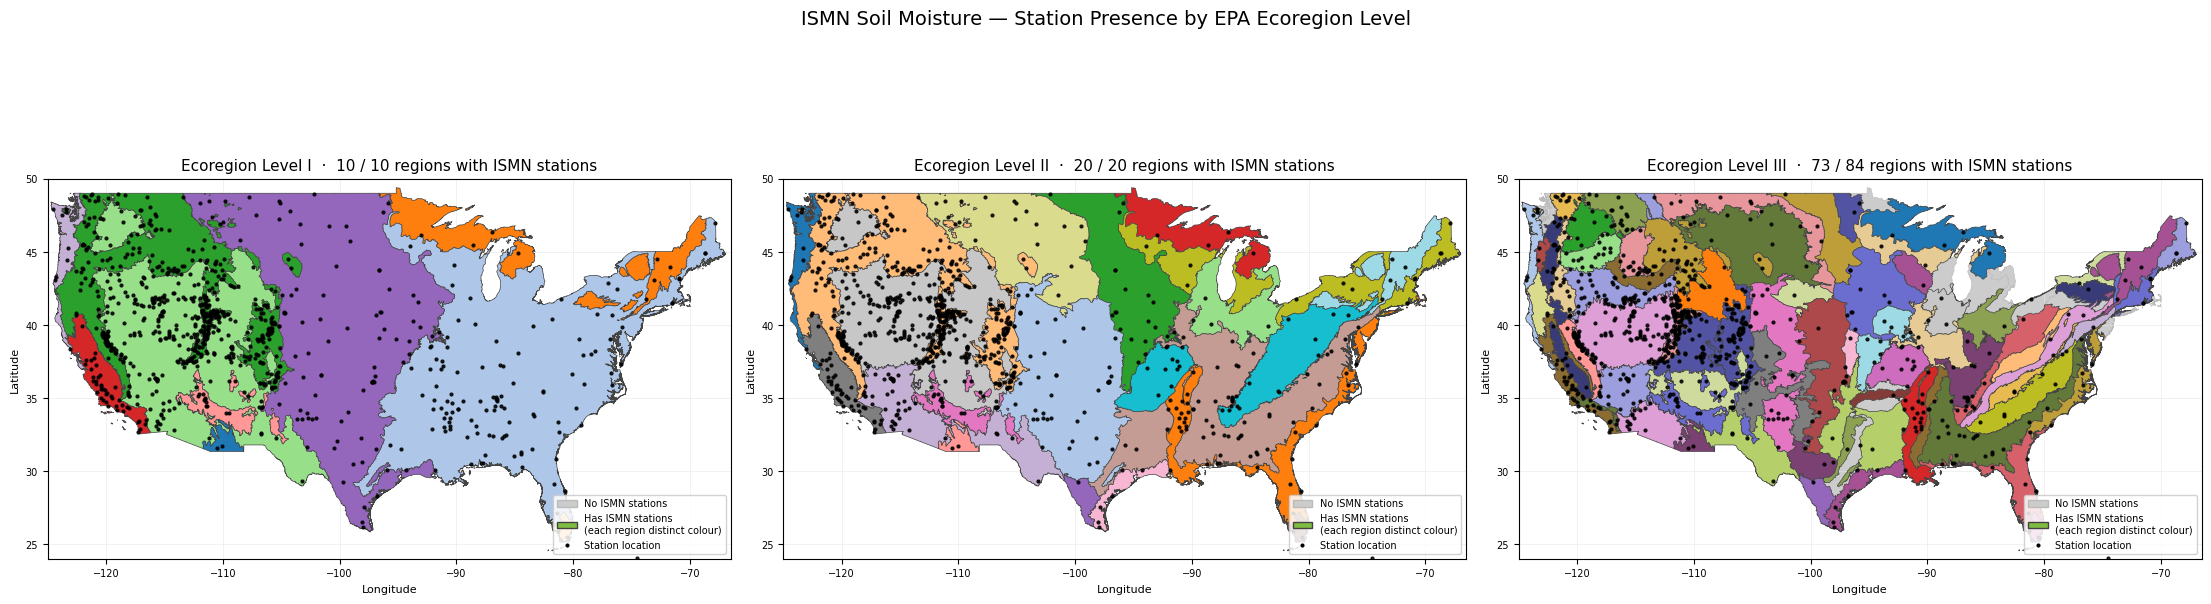

In [7]:
def _set_extent(ax):
    lon_min, lon_max, lat_min, lat_max = EXTENT
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    center_lat = (lat_min + lat_max) / 2.0
    ax.set_aspect(1.0 / max(0.2, abs(math.cos(math.radians(center_lat)))))


def _region_colors(gdf, code_col):
    """Map each unique region code to a distinct colour from a qualitative palette."""
    codes = sorted(gdf[code_col].unique())
    # Blend tab20 + tab20b for up to 40 distinct hues; cycle beyond that
    palette = [cm.tab20(i % 20) if i < 20 else cm.tab20b(i % 20) for i in range(len(codes))]
    # Shuffle so adjacent index codes don't share similar hues
    rng = np.random.default_rng(seed=42)
    rng.shuffle(palette)
    return dict(zip(codes, palette))


def plot_level(ax, level_cfg: dict) -> None:
    key      = level_cfg["key"]
    label    = level_cfg["label"]
    code_col = level_cfg["code"]
    gdf      = level_gdfs[key]

    color_map = _region_colors(gdf, code_col)

    no_stn  = gdf[~gdf["has_stations"]]
    has_stn = gdf[gdf["has_stations"]]

    # Regions without stations: grey, no edge emphasis
    if not no_stn.empty:
        no_stn.plot(ax=ax, color="#cccccc", edgecolor="#bbbbbb",
                    linewidth=0.4, zorder=1, aspect=None)

    # Regions with stations: each gets its own distinct colour
    if not has_stn.empty:
        colors = [color_map[c] for c in has_stn[code_col]]
        has_stn.plot(ax=ax, color=colors, edgecolor="#444444",
                     linewidth=0.5, zorder=2, aspect=None)

    ax.scatter(
        points_gdf.geometry.x, points_gdf.geometry.y,
        s=DOT_SIZE, c="black", marker="o", linewidths=0, alpha=0.9, zorder=3,
    )

    _set_extent(ax)

    covered = int(gdf["has_stations"].sum())
    total   = len(gdf)
    ax.set_title(
        f"Ecoregion {label}  ·  {covered} / {total} regions with ISMN stations",
        fontsize=11,
    )
    ax.set_xlabel("Longitude", fontsize=8)
    ax.set_ylabel("Latitude", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, color="0.90", linewidth=0.4, zorder=0)

    legend_handles = [
        mpatches.Patch(facecolor="#cccccc", edgecolor="#bbbbbb", label="No ISMN stations"),
        mpatches.Patch(facecolor="#7fbc41", edgecolor="#444444", label="Has ISMN stations\n(each region distinct colour)"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="black",
                   markersize=4, label="Station location"),
    ]
    ax.legend(handles=legend_handles, loc="lower right", fontsize=7, framealpha=0.85)


fig, axes = plt.subplots(1, 3, figsize=(22, 7), constrained_layout=True)

for ax, cfg in zip(axes, LEVELS):
    plot_level(ax, cfg)

suptitle = "ISMN Soil Moisture — Station Presence by EPA Ecoregion Level"
if MONTH:
    suptitle += f"  ({MONTH})"
fig.suptitle(suptitle, fontsize=14)

fig.savefig(OUTPUT, dpi=150, bbox_inches="tight")
print(f"Saved {OUTPUT}")
plt.show()

## 7 · Individual level maps (optional)

Re-run any single level at higher resolution.

Saved visualize_ismn_ecoregion_iii.png


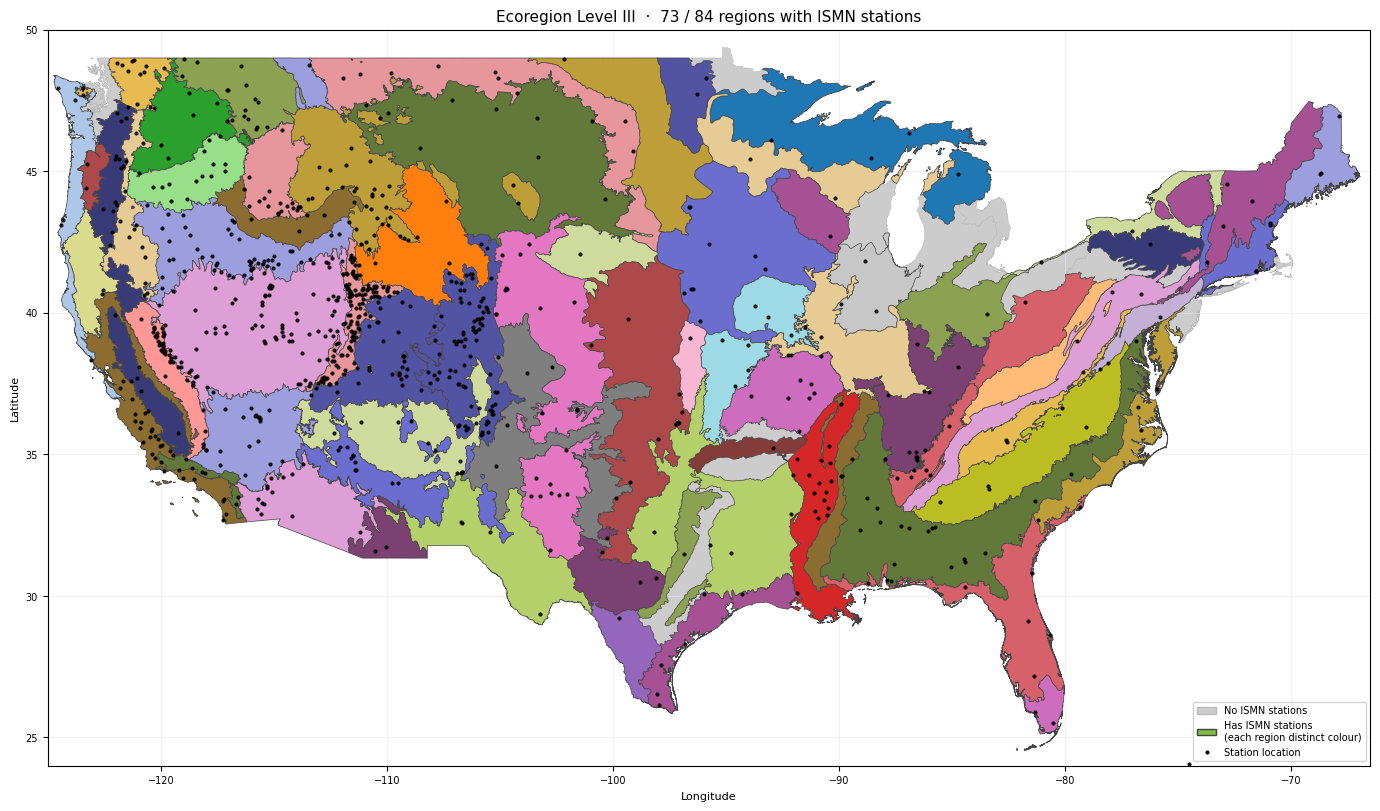

In [8]:
SINGLE_LEVEL = "III"   # change to I, II, or III
SINGLE_DPI   = 300

cfg = next(c for c in LEVELS if c["key"] == SINGLE_LEVEL)
fig_s, ax_s = plt.subplots(figsize=(14, 8), constrained_layout=True)
plot_level(ax_s, cfg)
out_single = ROOT / f"visualize_ismn_ecoregion_{SINGLE_LEVEL.lower()}.png"
fig_s.savefig(out_single, dpi=SINGLE_DPI, bbox_inches="tight")
print(f"Saved {out_single}")
plt.show()

## 8 · Station-count summary table per level

In [9]:
for cfg in LEVELS:
    key      = cfg["key"]
    code_col = cfg["code"]
    gdf      = level_gdfs[key]

    print(f"\n=== Ecoregion {cfg['label']} — top 6 by ISMN station count ===")
    top = (
        gdf[[code_col, "station_count"]]
        .query("station_count > 0")
        .sort_values("station_count", ascending=False)
        .head(20)
        .reset_index(drop=True)
    )
    print(top.to_string(index=False))


=== Ecoregion Level I — top 6 by ISMN station count ===
NA_L1CODE  station_count
        6            372
       10            231
        8            115
        9             93
       11             42
       13             13
        5              8
        7              7
       12              2
       15              2

=== Ecoregion Level II — top 6 by ISMN station count ===
NA_L2CODE  station_count
      6.2            372
     10.1            192
      8.3             47
      9.4             46
     11.1             42
     10.2             39
      8.5             28
      8.4             23
      9.3             20
      9.2             20
      8.1             13
     13.1             13
      7.1              7
      9.5              6
      8.2              4
      5.3              4
      5.2              4
     15.4              2
     12.1              2
      9.6              1

=== Ecoregion Level III — top 6 by ISMN station count ===
NA_L3CODE  station_count
 